In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

In [19]:
df = df.iloc[:, :2]
df.columns = ['label', 'text']

In [20]:
print(f"Dataset Shape: {df.shape}\n")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True) * 100)

Dataset Shape: (5572, 2)

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB
None

Missing Values:
label    0
text     0
dtype: int64

Class Distribution:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [21]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
# Check count
print(f"Duplicates: {df.duplicated().sum()}")

# Drop duplicates
df = df.drop_duplicates(keep='first')
print(f"Shape after removing duplicates: {df.shape}")

Duplicates: 403
Shape after removing duplicates: (5169, 2)


In [23]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

# Calculate character, word, and sentence lengths
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

# Compare statistical summaries for ham vs. spam
df[df['label'] == 'ham'][['num_characters', 'num_words', 'num_sentences']].describe()
df[df['label'] == 'spam'][['num_characters', 'num_words', 'num_sentences']].describe()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nourm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nourm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


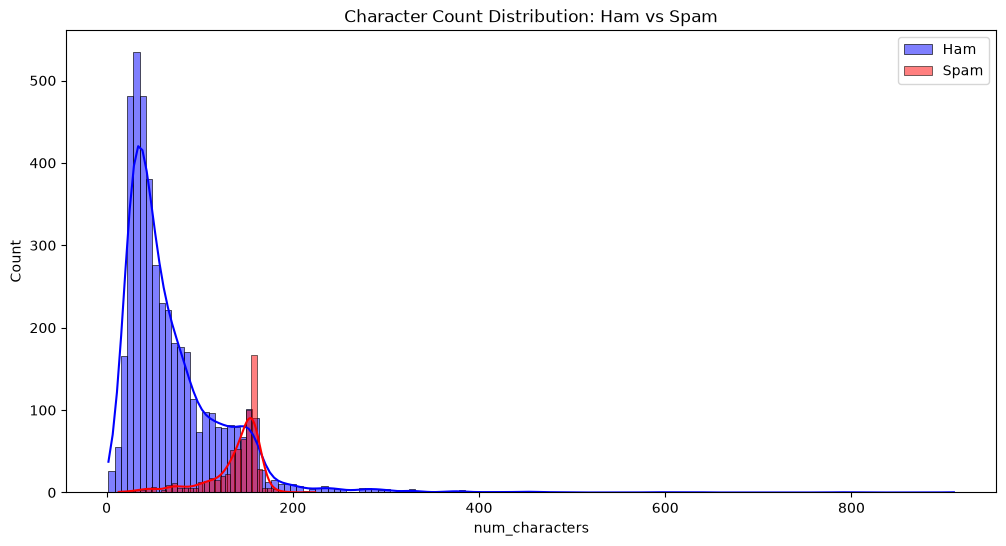

In [24]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['label'] == 'ham']['num_characters'], color='blue', label='Ham', kde=True)
sns.histplot(df[df['label'] == 'spam']['num_characters'], color='red', label='Spam', kde=True)
plt.title('Character Count Distribution: Ham vs Spam')
plt.legend()
plt.show()

In [ ]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')

ps = PorterStemmer()

def transform_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Tokenize into words
    words = nltk.word_tokenize(text)
    
    # 3. Keep only alphanumeric words
    y = [i for i in words if i.isalnum()]
    
    # 4. Remove stopwords and punctuation
    y = [i for i in y if i not in stopwords.words('english') and i not in string.punctuation]
    
    # 5. Apply Stemming
    y = [ps.stem(i) for i in y]
    
    return " ".join(y)

# Example check
sample = "Did you hear about the NEW offer? Text WIN to 80085 now!!"
print("Before:", sample)
print("After :", transform_text(sample))

Before: Did you hear about the NEW offer? Text WIN to 80085 now!!
After : hear new offer text win 80085


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nourm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
df['transformed_text'] = df['text'].apply(transform_text)
df[['text', 'transformed_text']].head()

,text,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=3000)

# X = Feature matrix (numbers), y = Target labels
X = tfidf.fit_transform(df['transformed_text']).toarray()

# Convert labels to 0 (ham) and 1 (spam)
y = df['label'].map({'ham': 0, 'spam': 1}).values

print("Feature matrix shape:", X.shape)
print("Target array shape:", y.shape)

Feature matrix shape: (5169, 3000)
Target array shape: (5169,)


In [13]:
from sklearn.model_selection import train_test_split

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (4135, 3000)
X_test shape:  (1034, 3000)


In [25]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Initialize models
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Support Vector Machine': SVC(kernel='sigmoid')
}

# Training and evaluation loop
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred) # avoid false positives
    rec = recall_score(y_test, y_pred)
    
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec}

# Display results comparison
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)

                         Accuracy  Precision    Recall
Multinomial Naive Bayes  0.974855   0.981651  0.816794
Logistic Regression      0.955513   1.000000  0.648855
Support Vector Machine   0.975822   0.973214  0.832061


In [26]:
import joblib

# Pick the trained Naive Bayes model
best_model = models['Multinomial Naive Bayes']

# Save weights
joblib.dump(tfidf, '../weights/vectorizer.pkl')
joblib.dump(best_model, '../weights/best_model.pkl')

print("Artifacts saved successfully!")

Artifacts saved successfully!


In [27]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    words = nltk.word_tokenize(text)
    
    # Keep alphanumeric words, remove stopwords & punctuation
    y = [i for i in words if i.isalnum()]
    y = [i for i in y if i not in stopwords.words('english') and i not in string.punctuation]
    y = [ps.stem(i) for i in y]
    
    return " ".join(y)

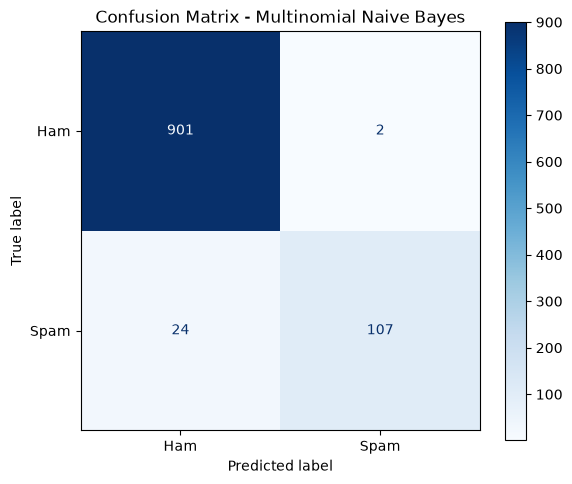

ROC-AUC Score: 0.9901


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_curve, 
    auc, 
    precision_recall_curve
)

# Pick best model and predict on test set
best_model = models['Multinomial Naive Bayes']
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 1. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=300)
plt.show()